# Visualization notebook for Indoor Scene Recognition

In [49]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np 
import os

In [39]:
img_dir = "Images"
# img_dir = 'drive/MyDrive/DS4420 project/Images'
category_names = ["public_spaces", "leisure", "store", "working_spaces", "home"]

category_counts = {}
room_counts = {}

for i in category_names:
    category_dir = os.path.join(img_dir, i)
    total = 0
    for j in os.listdir(category_dir):
        room_dir = os.path.join(category_dir, j)
        if not os.path.isdir(room_dir):
            continue
        n = len([f for f in os.listdir(room_dir) if f.endswith('.jpg')])
        room_counts[f"{i}/{j}"] = (n, i)
        total += n
    category_counts[i] = total


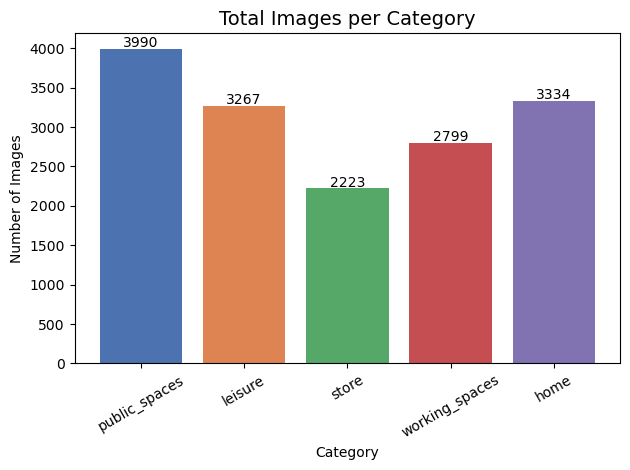

In [18]:
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

plt.bar(category_counts.keys(), category_counts.values(), color=colors)
plt.title('Total Images per Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Number of Images')
plt.tick_params(axis='x', rotation=30)
for i, (k, v) in enumerate(category_counts.items()):
    plt.text(i, v + 20, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

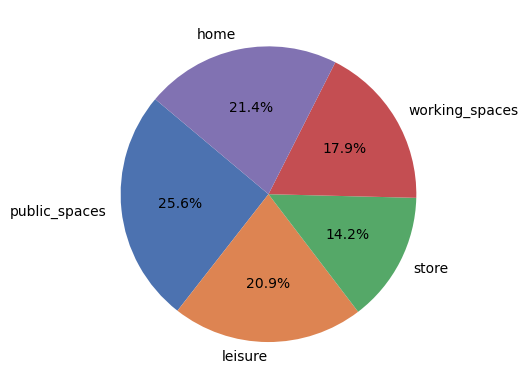

In [19]:
plt.pie(
    category_counts.values(),
    labels=category_counts.keys(),
    autopct='%1.1f%%',
    colors=colors,
    startangle=140
)
plt.show()

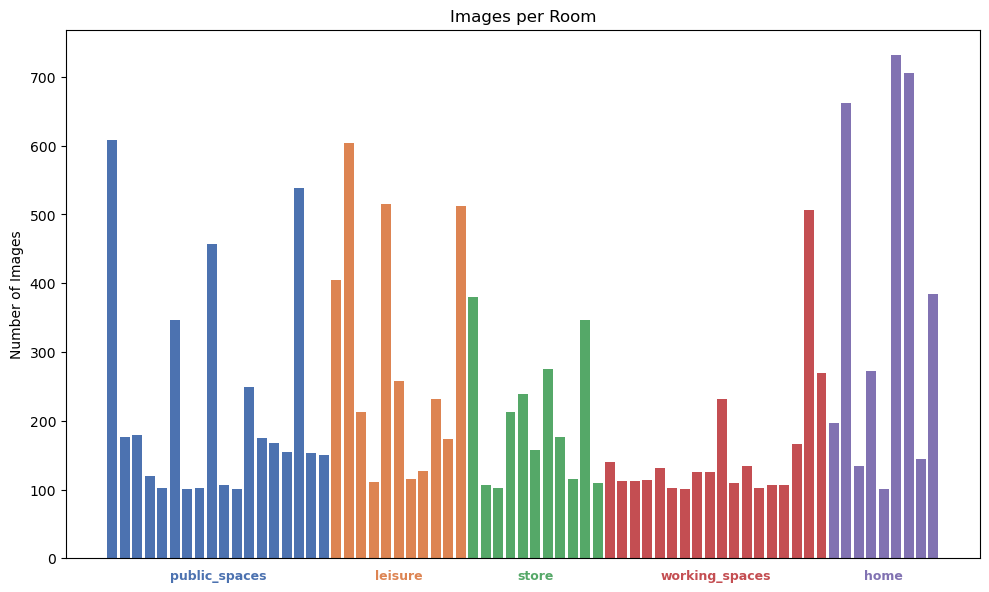

In [61]:
color_map = dict(zip(category_names, colors))
room_labels = list(room_counts.keys())
room_values = [v[0] for v in room_counts.values()]
room_colors = [color_map[v[1]] for v in room_counts.values()]

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(range(len(room_labels)), room_values, color=room_colors)
ax.set_title('Images per Room')
ax.set_ylabel('Number of Images')
ax.set_xticks([])

# add category name in the middle 
for category in category_names:
    indices = [i for i, (k, v) in enumerate(room_counts.items()) if v[1] == category]
    mid = np.mean(indices)
    ax.text(mid, -30, category, ha='center', fontsize=9, color=color_map[category], fontweight='bold')
    
plt.tight_layout()
plt.show()